In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from  sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.datasets import make_blobs
x , _ = make_blobs(n_samples= 300 , centers= 4 , random_state = 42)

In [2]:
arr =[]
for k in range ( 1 , 11 ):
    kmea=KMeans(random_state=42,n_clusters = k,n_init = 10 )
    kmea.fit(x)
    arr.append(kmea.inertia_)

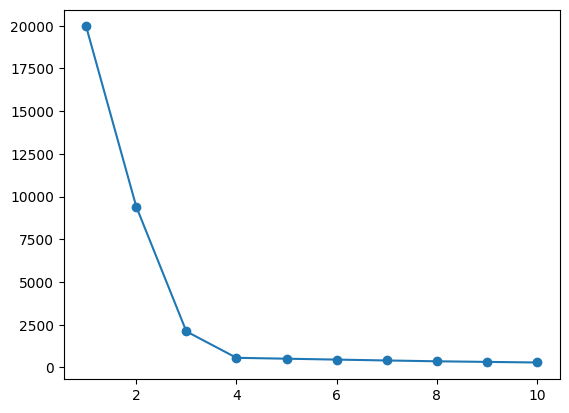

In [3]:
plt.plot(range ( 1 , 11 ),arr,marker = "o")

In [7]:
from  scipy.cluster.hierarchy import dendrogram , linkage
import seaborn as sns

In [5]:
hir = AgglomerativeClustering(n_clusters=4,linkage="ward")
y = hir.fit_predict(x)

In [6]:
dendrogram

<function scipy.cluster.hierarchy.dendrogram(Z, p=30, truncate_mode=None, color_threshold=None, get_leaves=True, orientation='top', labels=None, count_sort=False, distance_sort=False, show_leaf_counts=True, no_plot=False, no_labels=False, leaf_font_size=None, leaf_rotation=None, leaf_label_func=None, show_contracted=False, link_color_func=None, ax=None, above_threshold_color='C0')>

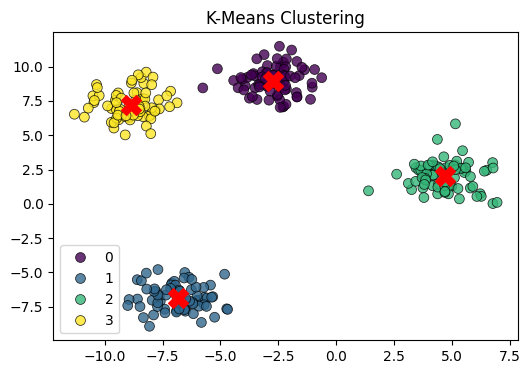

In [8]:
X, y = make_blobs(n_samples=300, centers=4, random_state=42)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis', s=50, alpha=0.8, edgecolor='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)
plt.title('K-Means Clustering')
plt.show()

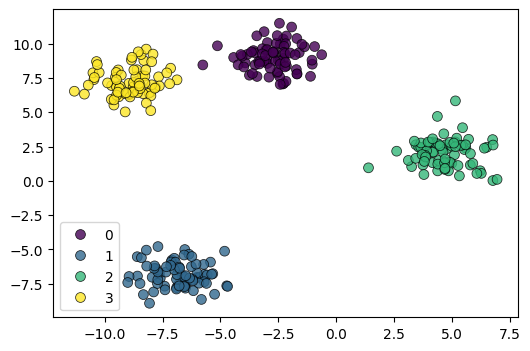

In [9]:
X,y=make_blobs(n_samples=300,centers=4,random_state=42)
hierarchical =AgglomerativeClustering(n_clusters= 4,linkage='ward')
hierarchical_predict=hierarchical.fit_predict(X)
plt.figure(figsize=(6, 4))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=hierarchical_predict, palette='viridis', s=50, alpha=0.8, edgecolor='k')
plt.show()


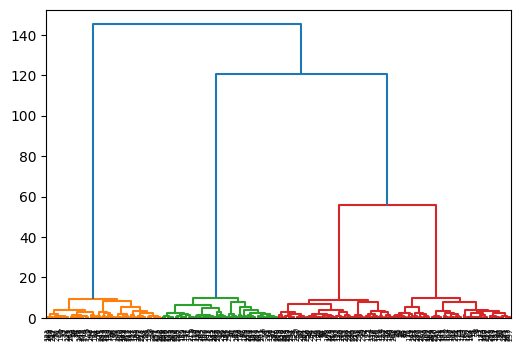

In [10]:
plt.figure(figsize=(6, 4))
Z = linkage(X, method='ward')  
dendrogram(Z)
plt.show()

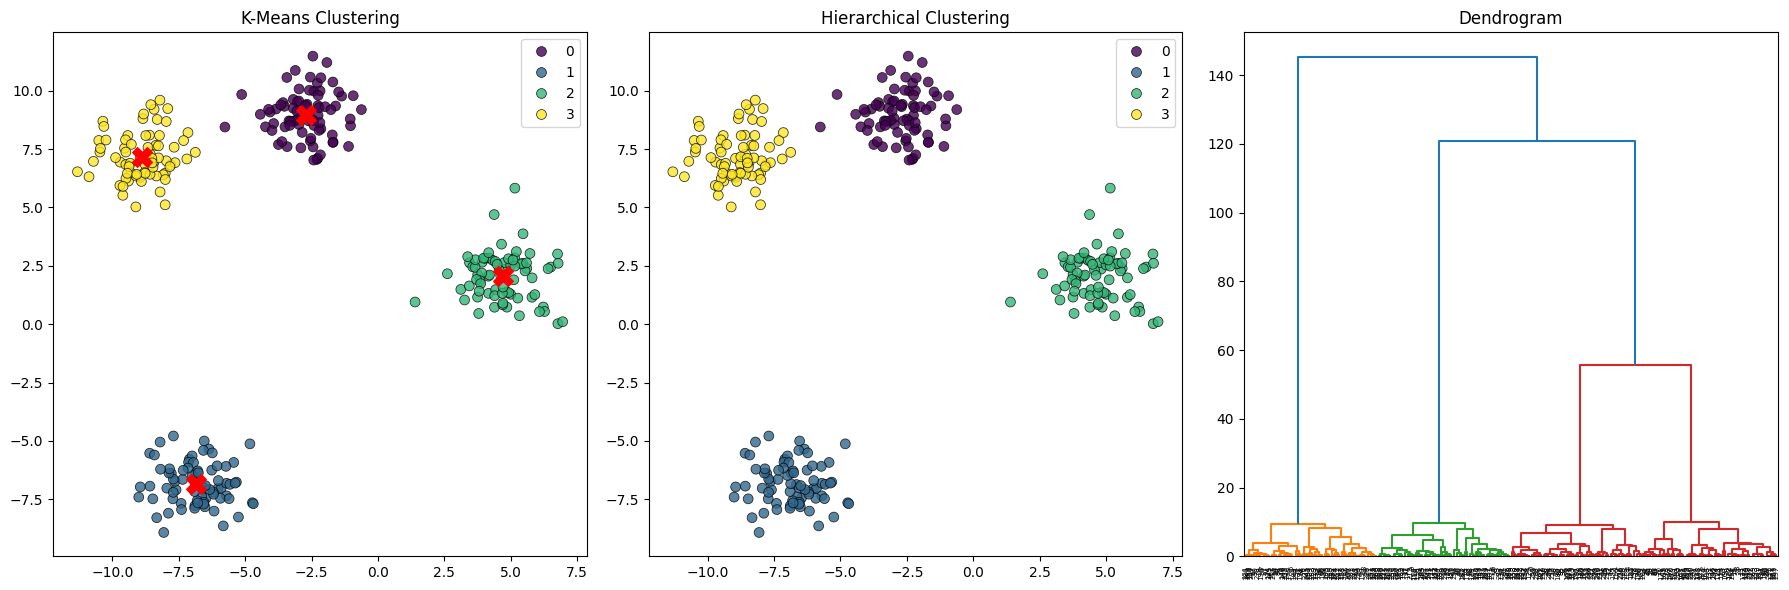

In [13]:
k=4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_
hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
hierarchical_predict = hierarchical.fit_predict(X)
Z = linkage(X, method='ward')
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(ax=axes[0], x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis', s=50, alpha=0.8, edgecolor='k')
axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)
axes[0].set_title('K-Means Clustering')
sns.scatterplot(ax=axes[1], x=X[:, 0], y=X[:, 1], hue=hierarchical_predict, palette='viridis', s=50, alpha=0.8, edgecolor='k')
axes[1].set_title('Hierarchical Clustering')
dendrogram(Z, ax=axes[2])
axes[2].set_title('Dendrogram')
plt.tight_layout()
plt.show()

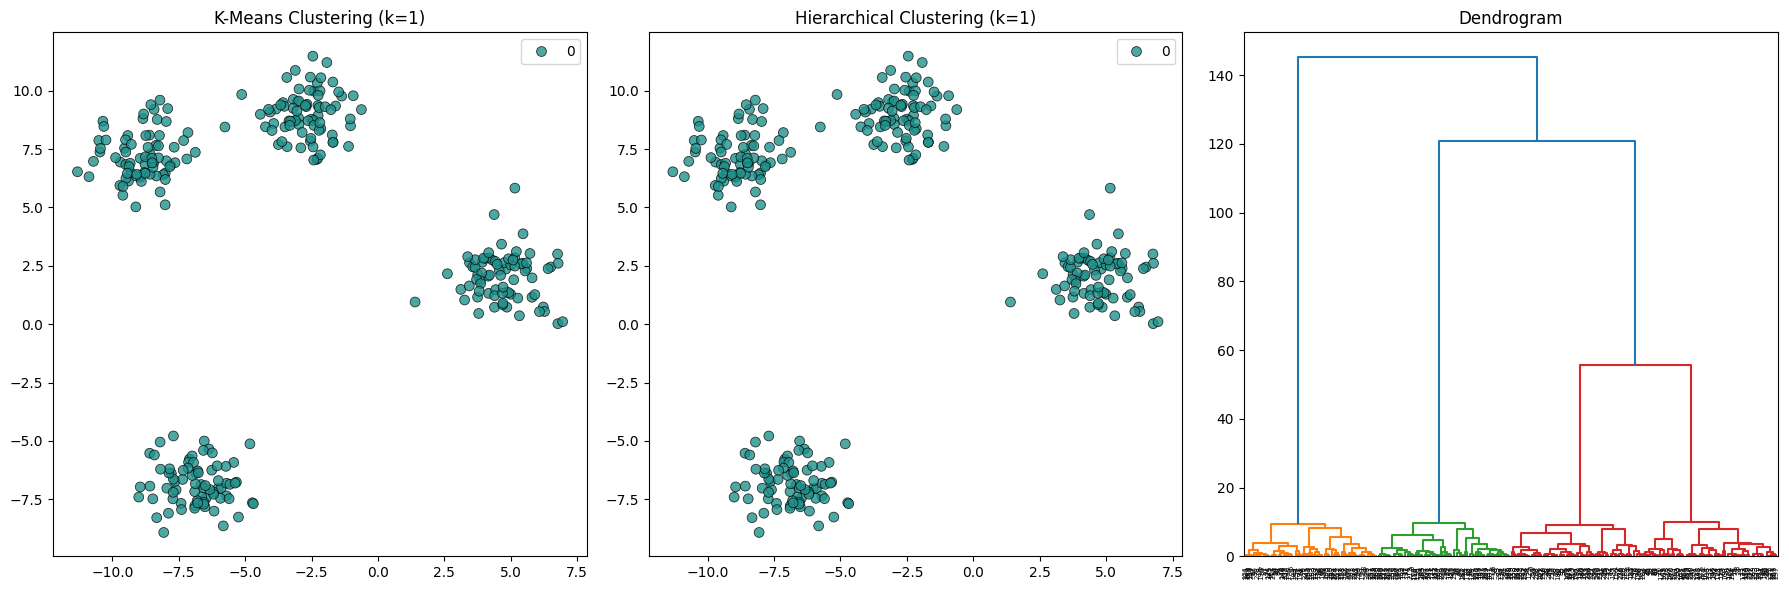

<Figure size 640x480 with 0 Axes>

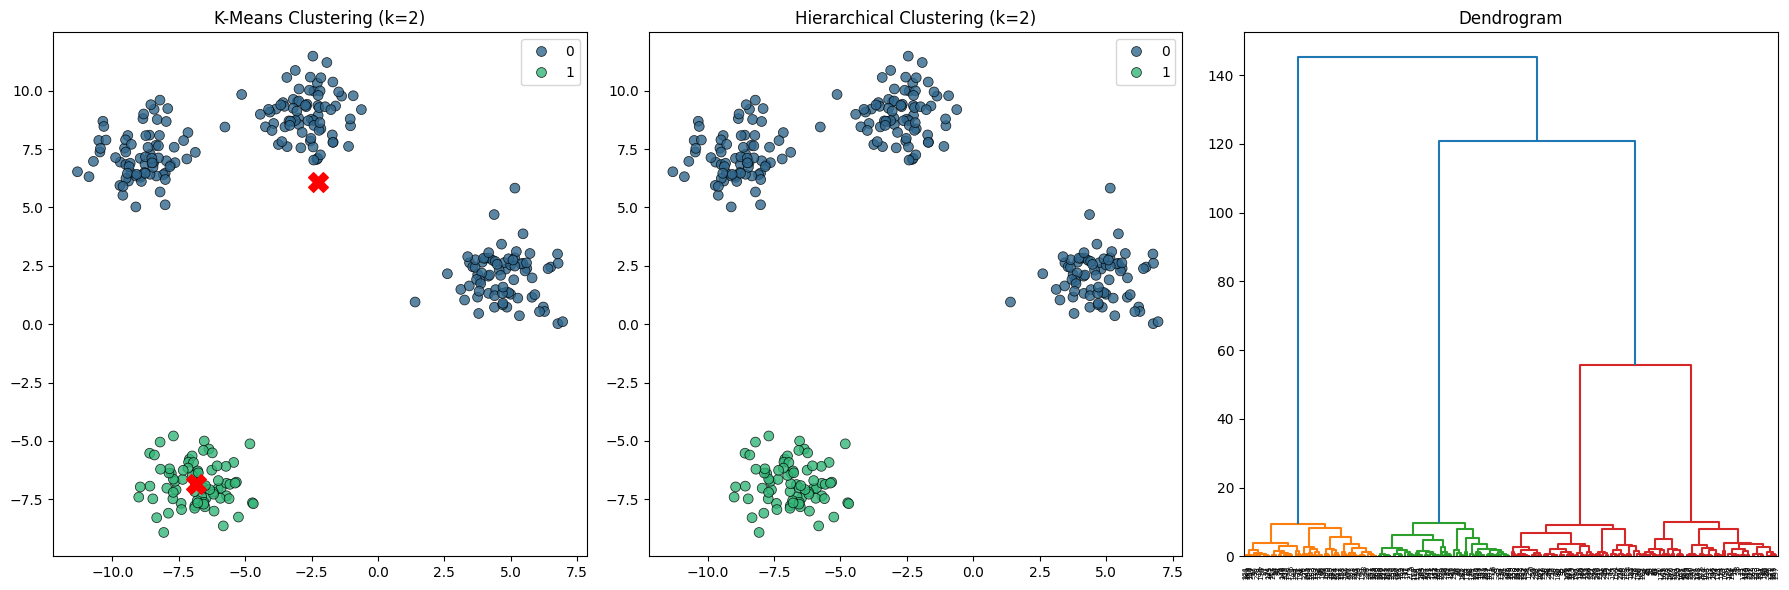

<Figure size 640x480 with 0 Axes>

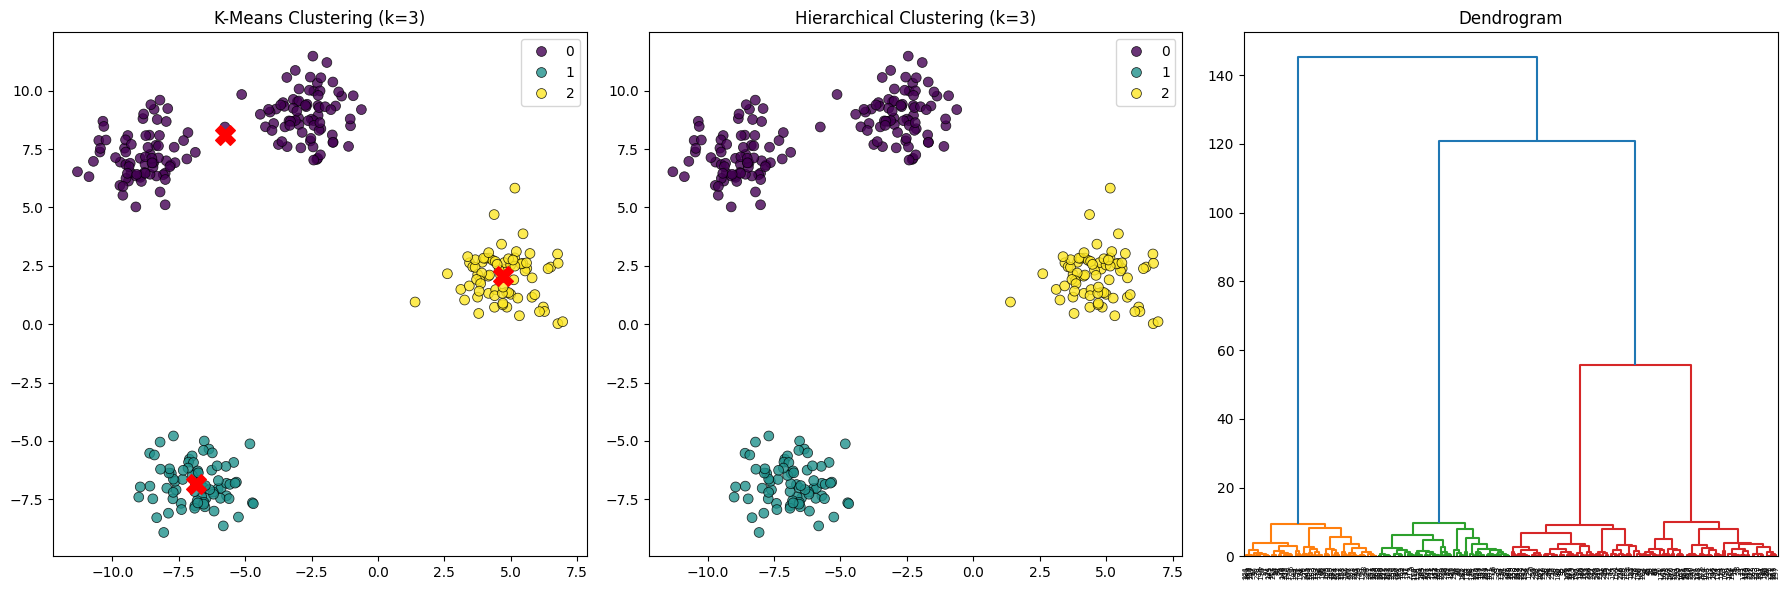

<Figure size 640x480 with 0 Axes>

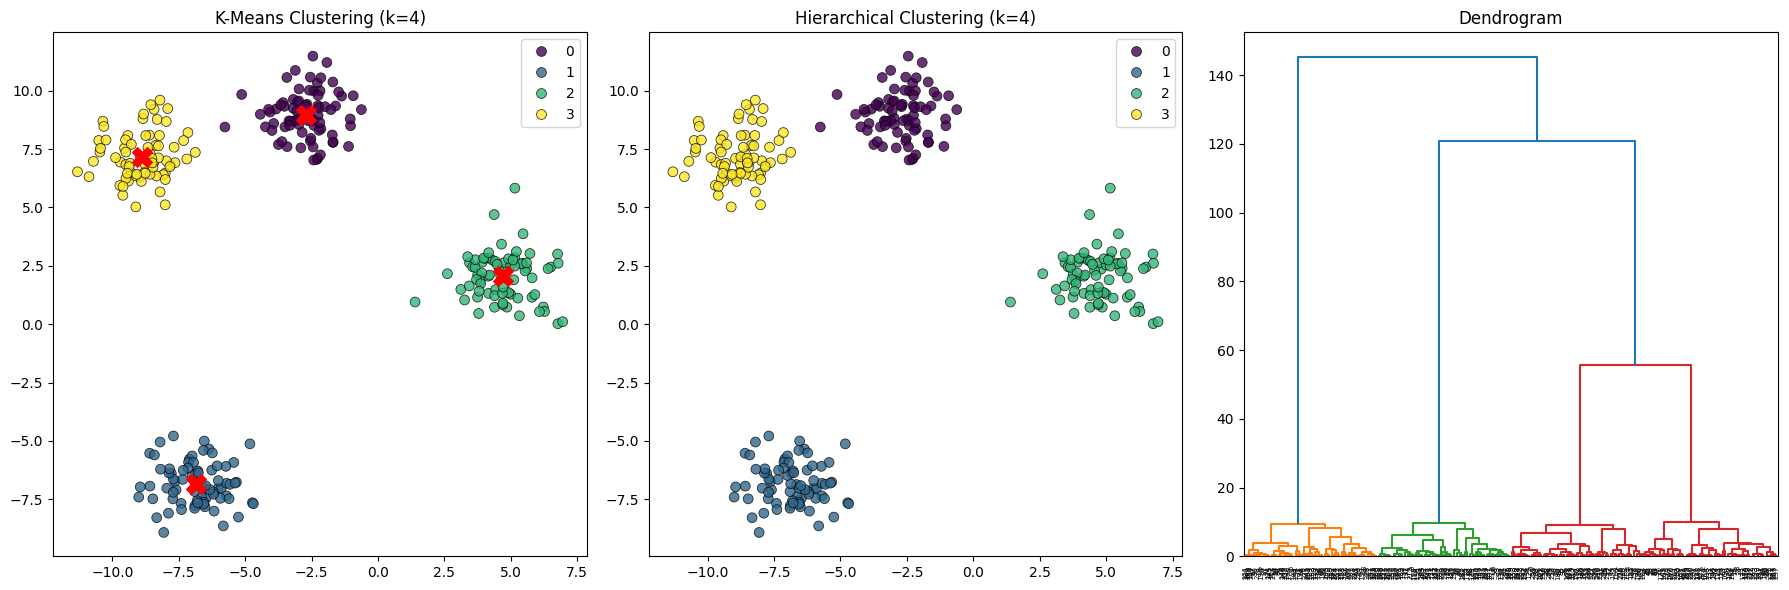

<Figure size 640x480 with 0 Axes>

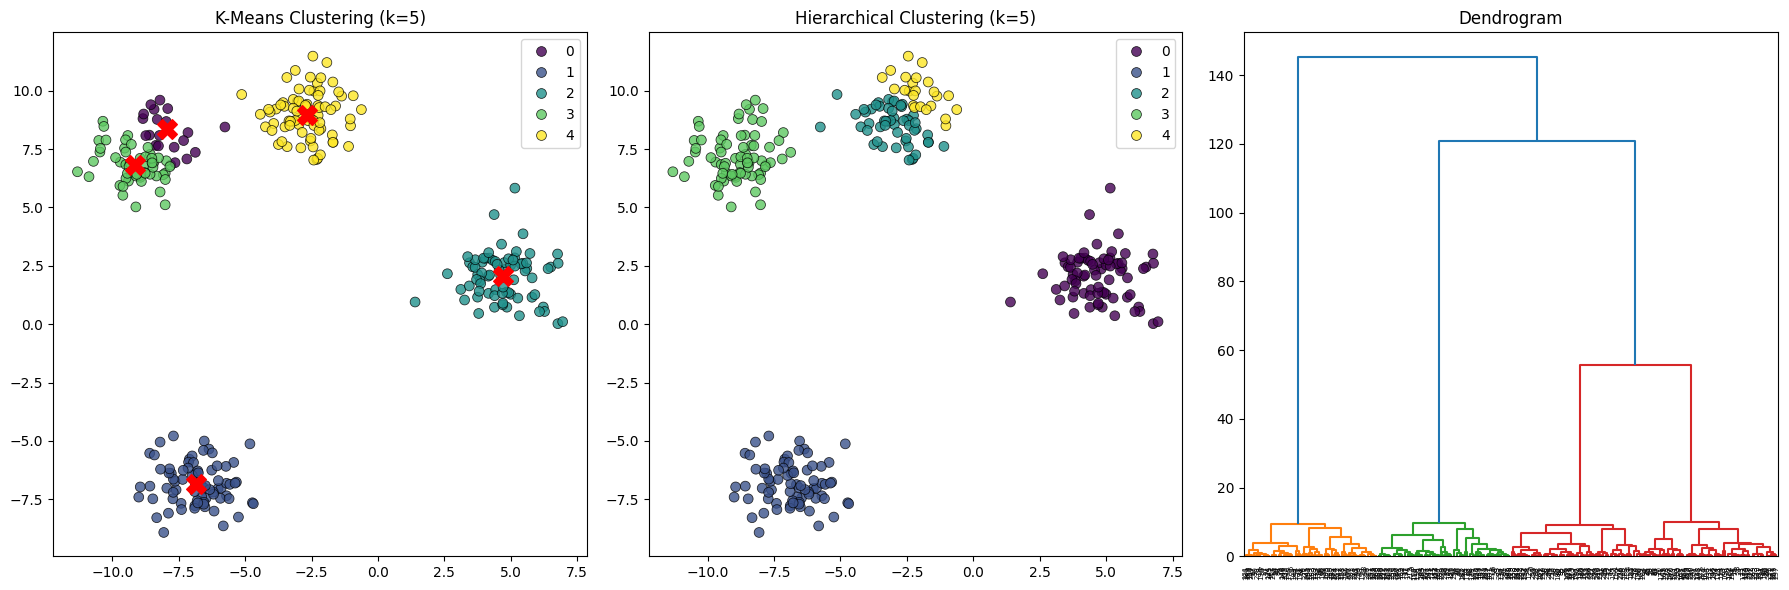

<Figure size 640x480 with 0 Axes>

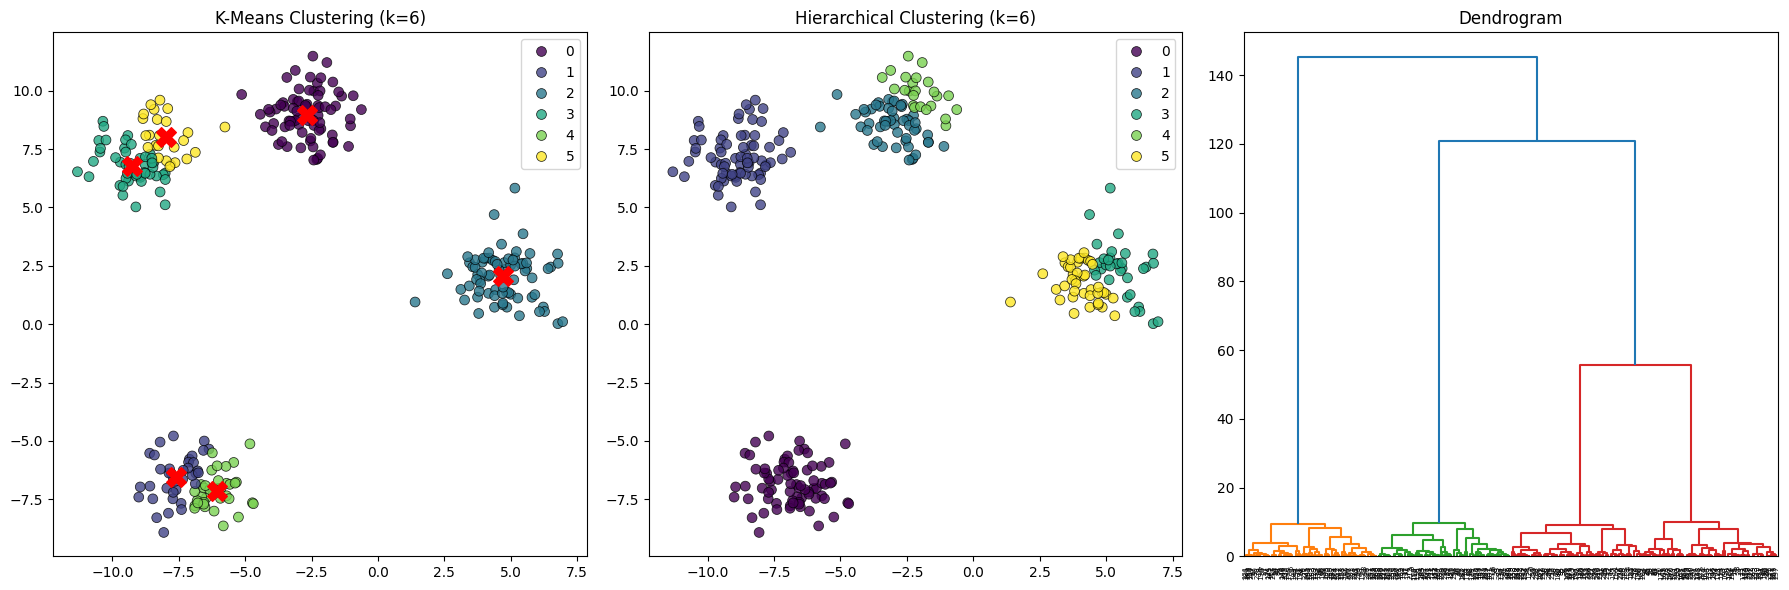

<Figure size 640x480 with 0 Axes>

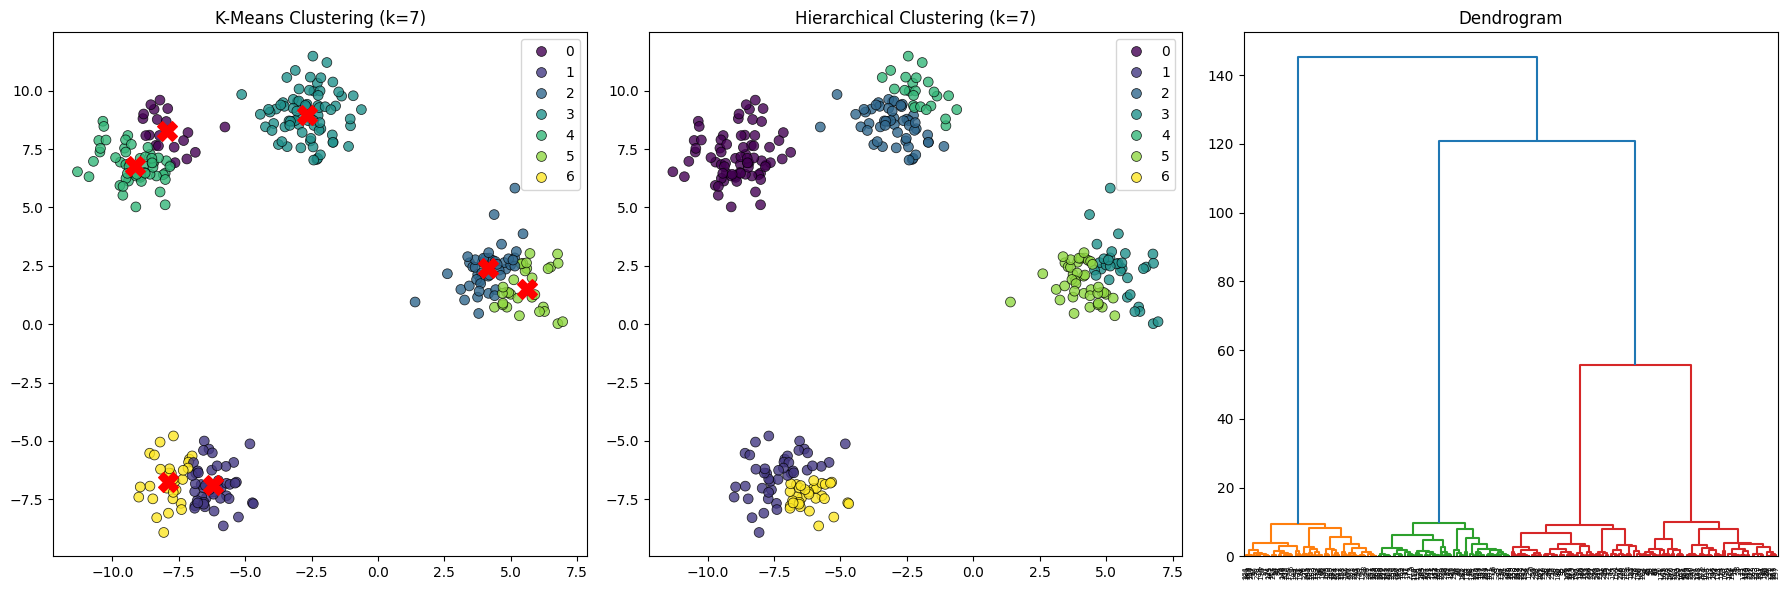

<Figure size 640x480 with 0 Axes>

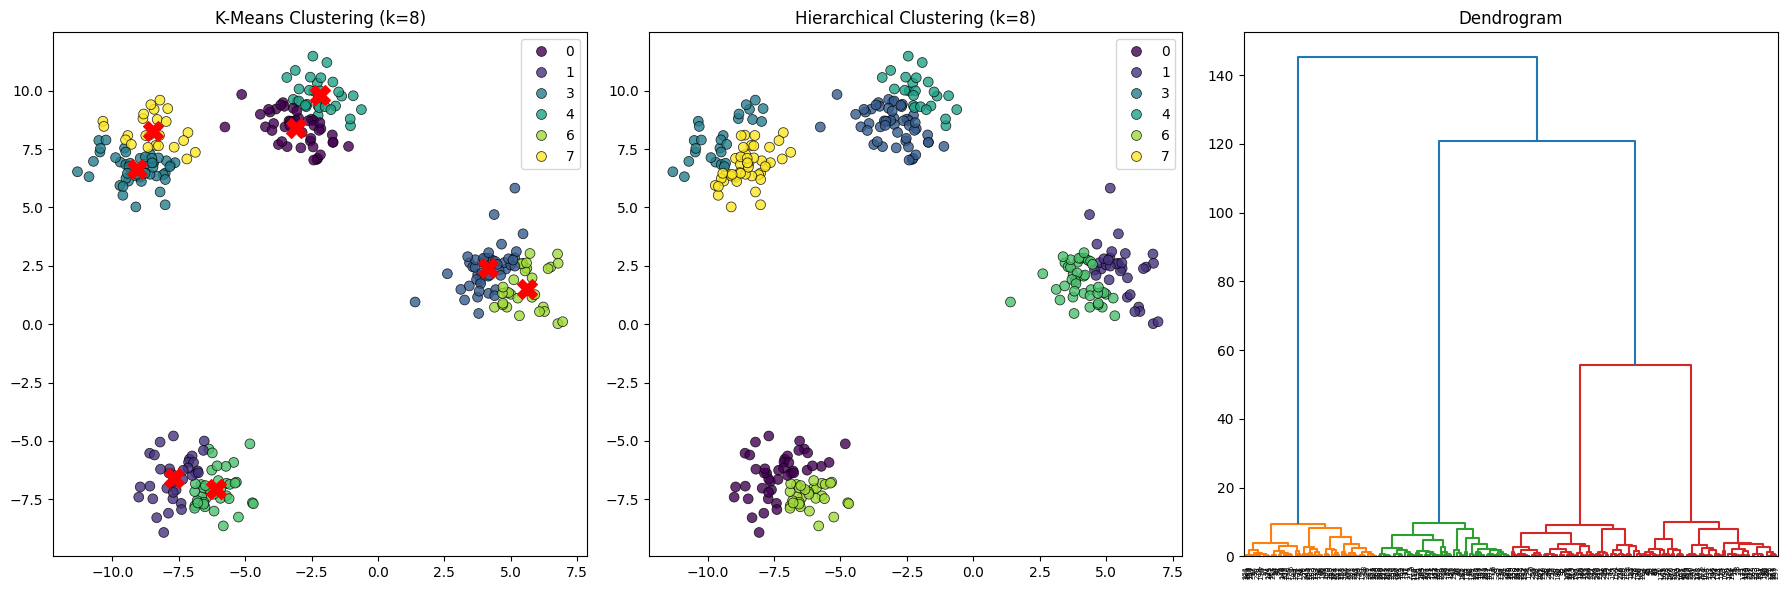

<Figure size 640x480 with 0 Axes>

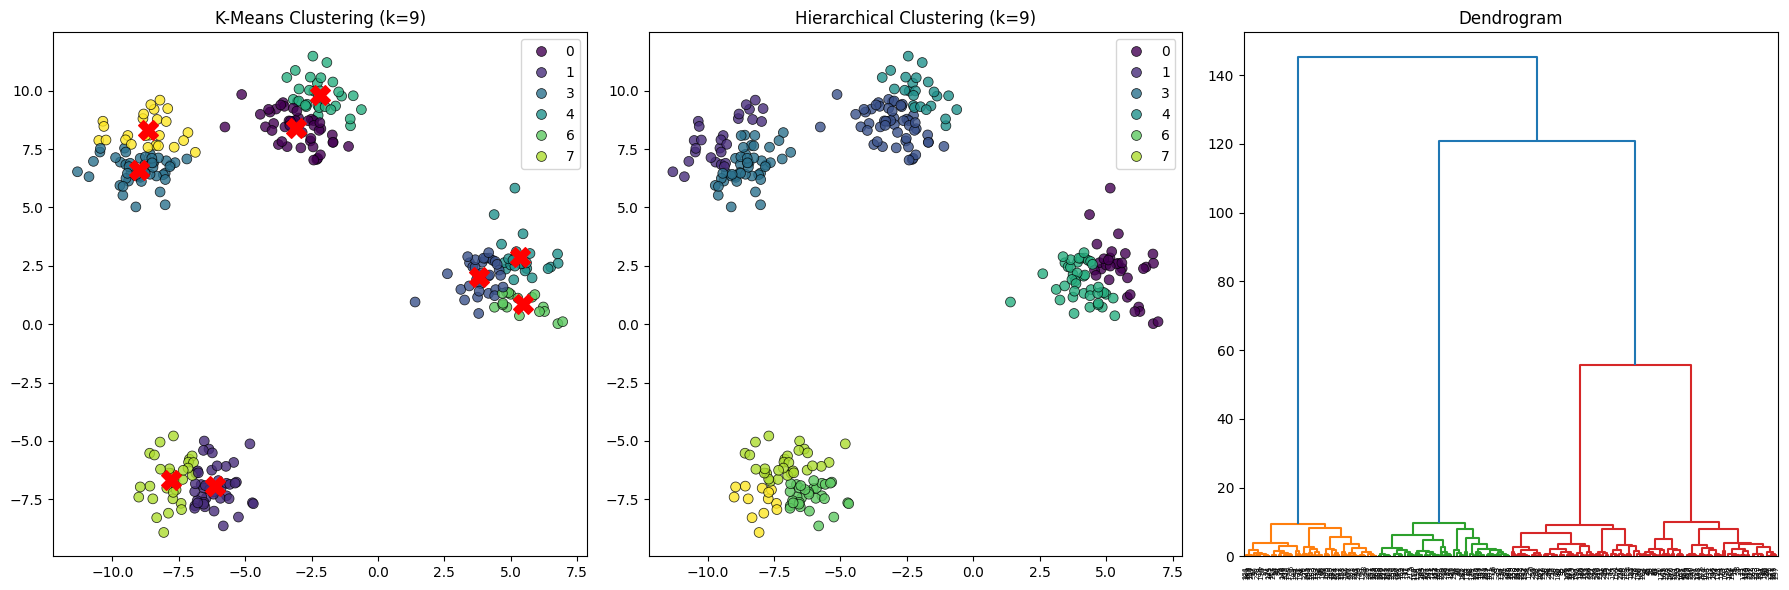

<Figure size 640x480 with 0 Axes>

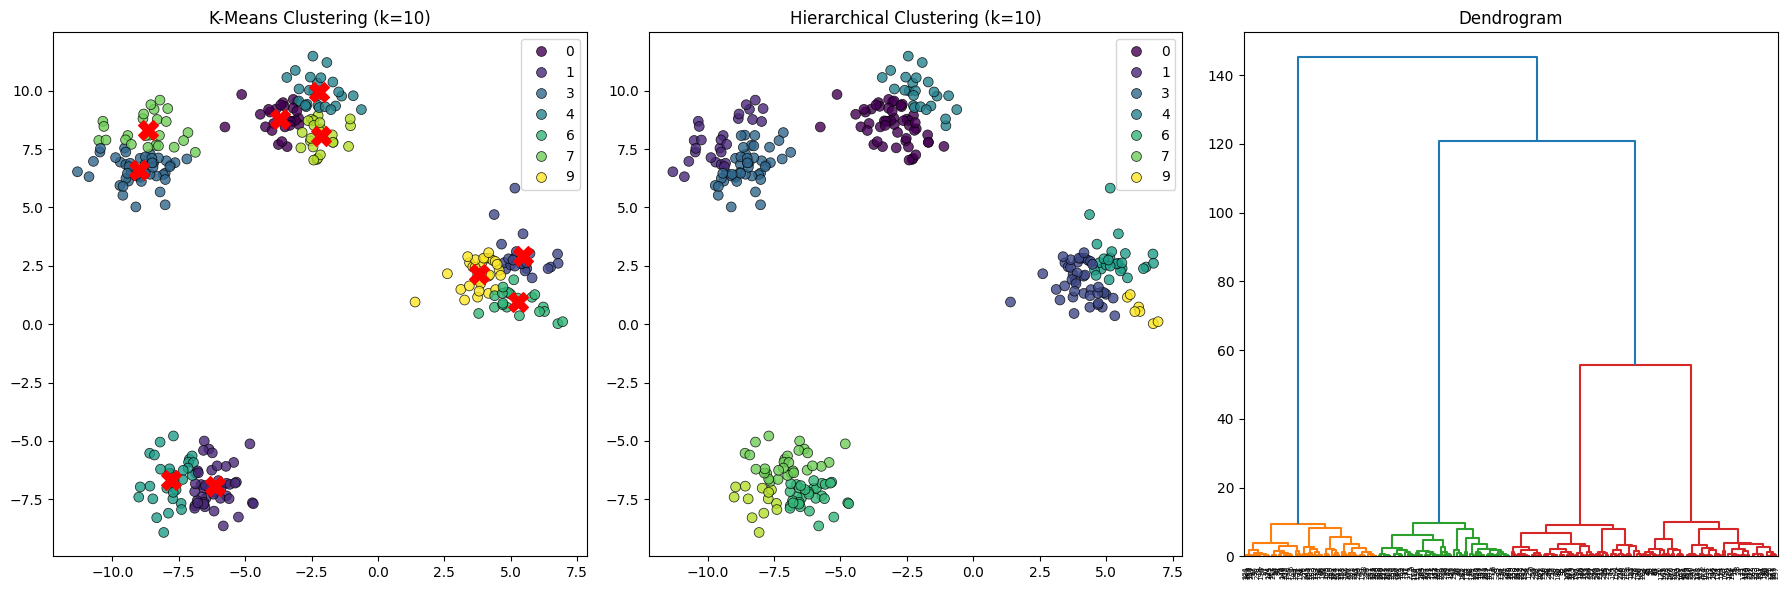

<Figure size 640x480 with 0 Axes>

In [ ]:

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    labels = kmeans.labels_
    centroids = kmeans.cluster_centers_
    hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    hierarchical_predict = hierarchical.fit_predict(X)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sns.scatterplot(ax=axes[0], x=X[:, 0], y=X[:, 1], hue=labels, palette='viridis', s=50, alpha=0.8, edgecolor='k')
    if k > 1:  
        axes[0].scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200)
    axes[0].set_title(f'K-Means Clustering (k={k})')
    sns.scatterplot(ax=axes[1], x=X[:, 0], y=X[:, 1], hue=hierarchical_predict, palette='viridis', s=50, alpha=0.8, edgecolor='k')
    axes[1].set_title(f'Hierarchical Clustering (k={k})')
    dendrogram(Z, ax=axes[2])
    axes[2].set_title('Dendrogram')
    plt.tight_layout()
    plt.show()
    plt.clf()


## Types of Linkage in Hierarchical Clustering

When performing hierarchical clustering, the `linkage` parameter determines how distances between clusters are calculated during the merging process. Here are the common types of linkage and their differences:

### 1. **Ward Linkage**
- **Objective**: Minimizes the total within-cluster variance (sum of squared differences) after merging.
- **How It Works**: Chooses the clusters whose merging results in the smallest increase in variance.
- **Key Advantage**: Produces compact and cohesive clusters, making it one of the most popular options.

---

### 2. **Single Linkage**
- **Objective**: Finds the closest distance between any two points in two clusters.
- **How It Works**: Merges the clusters containing the two closest data points.
- **Key Drawback**: Can lead to the "chaining effect," producing elongated clusters.

---

### 3. **Complete Linkage**
- **Objective**: Calculates the farthest distance between any two points in two clusters.
- **How It Works**: Merges the clusters with the smallest maximum distance between any two points.
- **Key Advantage**: Produces tight, compact clusters, avoiding the chaining effect.

---

### 4. **Average Linkage**
- **Objective**: Uses the average of all pairwise distances between points in two clusters.
- **How It Works**: Computes the mean distance between all points in two clusters and merges the closest clusters based on this average.
- **Balance**: Offers a middle ground between single and complete linkage.

---

### 5. **Centroid Linkage**
- **Objective**: Considers the distance between the centroids (geometric centers) of two clusters.
- **How It Works**: Calculates the Euclidean distance between the centroids of two clusters.
- **Potential Issue**: May distort hierarchical structures if centroids shift significantly during merging.

---

### 6. **Median Linkage**
- **How It Works**: Similar to centroid linkage but uses median values instead of centroids.
- **Key Use**: Less commonly used but can be effective in specific datasets.

---

### Choosing the Best Linkage
- **Ward**: Ideal for reducing variance and producing tightly-knit clusters.
- **Single**: Good for detecting clusters with chaining or sequences.
- **Complete**: Useful for compact cluster formation.
- **Average**: Balanced approach for many clustering problems.

Selecting the appropriate linkage depends on the nature of your data and the specific goals of your analysis.